In [36]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving data.xlsx to data (28).xlsx


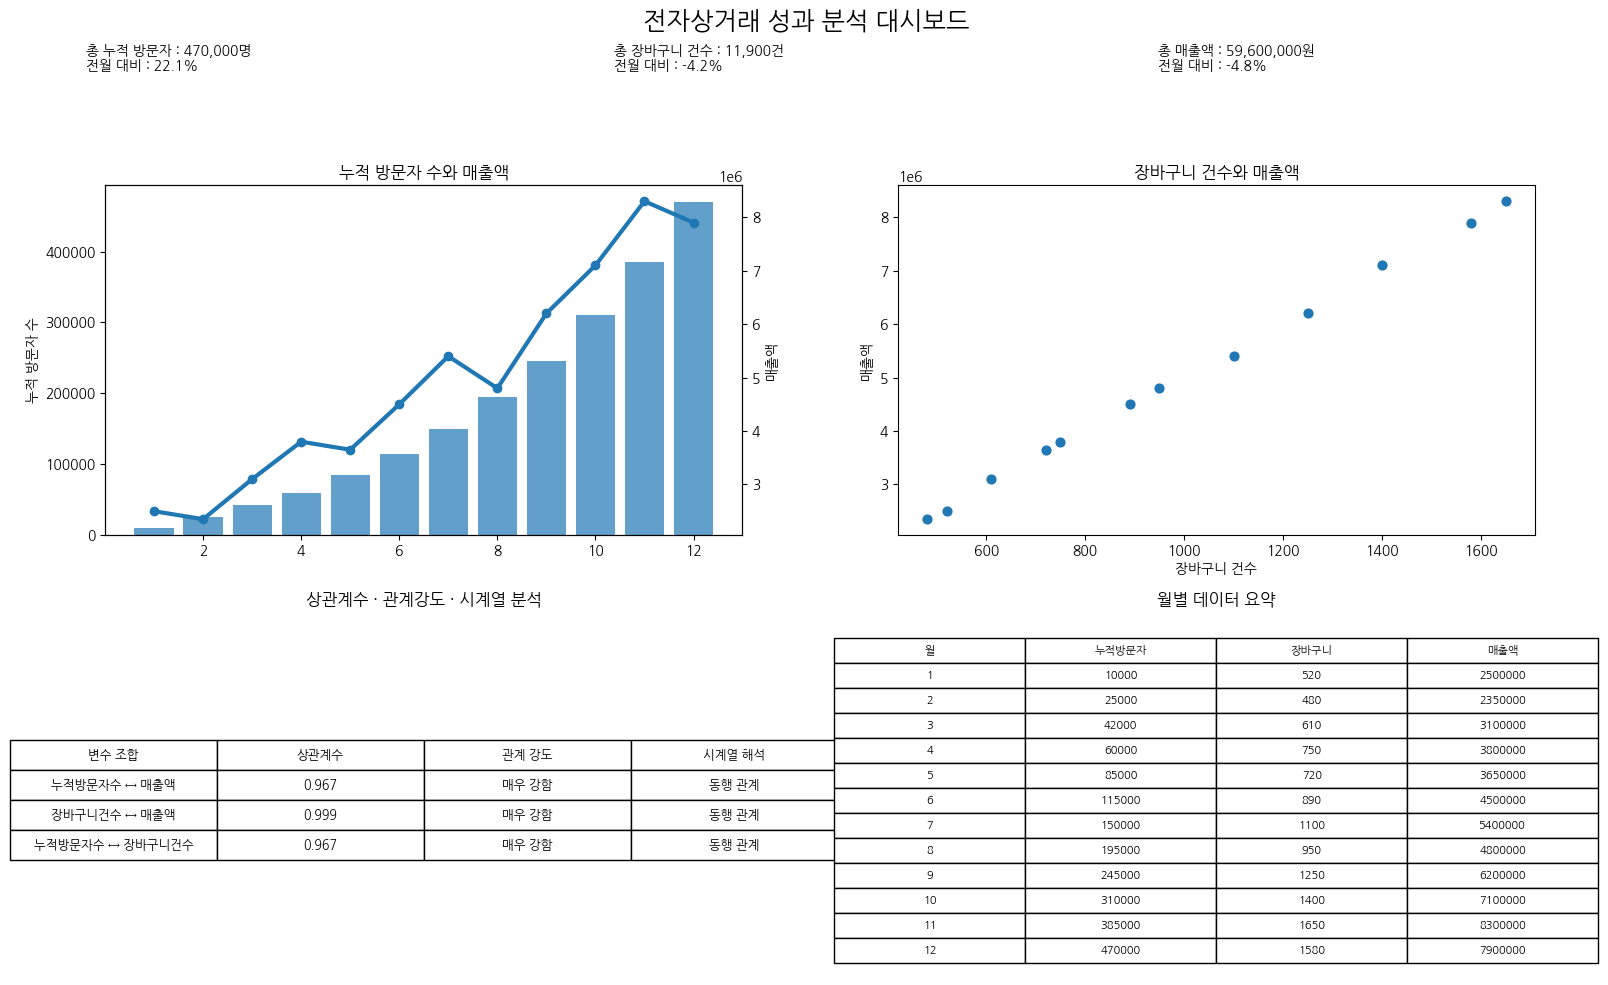

In [39]:
!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 엑셀 업로드
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

# ============================================================
# 컬럼명 지정
# ============================================================

df.columns = [
    "월",
    "누적방문자",
    "장바구니",
    "매출액"
]

# ============================================================
# 신규 방문자 계산
# ============================================================

df["신규방문자"] = df["누적방문자"].diff()
df.loc[0, "신규방문자"] = df.loc[0, "누적방문자"]

# ============================================================
# KPI 계산
# ============================================================

총누적방문자 = df["누적방문자"].iloc[-1]
총장바구니건수 = df["장바구니"].sum()
총매출액 = df["매출액"].sum()

방문자증감률 = (
    (df["누적방문자"].iloc[-1] -
     df["누적방문자"].iloc[-2])
    / df["누적방문자"].iloc[-2]
) * 100

장바구니증감률 = (
    (df["장바구니"].iloc[-1] -
     df["장바구니"].iloc[-2])
    / df["장바구니"].iloc[-2]
) * 100

매출증감률 = (
    (df["매출액"].iloc[-1] -
     df["매출액"].iloc[-2])
    / df["매출액"].iloc[-2]
) * 100

# ============================================================
# 상관분석
# ============================================================

corr_vm = df["누적방문자"].corr(df["매출액"])
corr_cm = df["장바구니"].corr(df["매출액"])
corr_vc = df["누적방문자"].corr(df["장바구니"])

def 관계강도(r):

    r = abs(r)

    if r >= 0.9:
        return "매우 강함"
    elif r >= 0.7:
        return "강함"
    elif r >= 0.5:
        return "보통"
    elif r >= 0.3:
        return "약함"
    else:
        return "매우 약함"

def 선행분석(x, y):

    현재 = df[x].corr(df[y])
    선행1개월 = df[x].shift(1).corr(df[y])

    if abs(선행1개월) > abs(현재):
        return "월별 선행 가능성"
    else:
        return "동행 관계"

corr_table = pd.DataFrame({
    "변수 조합":[
        "누적방문자수 ↔ 매출액",
        "장바구니건수 ↔ 매출액",
        "누적방문자수 ↔ 장바구니건수"
    ],
    "상관계수":[
        round(corr_vm,3),
        round(corr_cm,3),
        round(corr_vc,3)
    ],
    "관계 강도":[
        관계강도(corr_vm),
        관계강도(corr_cm),
        관계강도(corr_vc)
    ],
    "시계열 해석":[
        선행분석("누적방문자","매출액"),
        선행분석("장바구니","매출액"),
        선행분석("누적방문자","장바구니")
    ]
})

# ============================================================
# 월별 요약표
# ============================================================

summary_table = df[
    [
        "월",
        "누적방문자",
        "장바구니",
        "매출액"
    ]
]

# ============================================================
# 대시보드
# ============================================================

fig = plt.figure(figsize=(16,10))

fig.suptitle(
    "전자상거래 성과 분석 대시보드",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# ============================================================
# KPI 영역
# ============================================================

fig.text(
    0.05,
    0.92,
    f"총 누적 방문자 : {총누적방문자:,.0f}명\n전월 대비 : {방문자증감률:.1f}%",
    fontsize=10
)

fig.text(
    0.38,
    0.92,
    f"총 장바구니 건수 : {총장바구니건수:,.0f}건\n전월 대비 : {장바구니증감률:.1f}%",
    fontsize=10
)

fig.text(
    0.72,
    0.92,
    f"총 매출액 : {총매출액:,.0f}원\n전월 대비 : {매출증감률:.1f}%",
    fontsize=10
)

# ============================================================
# 1. 누적방문자 vs 매출액
# ============================================================

ax1 = plt.subplot(2,2,1)

ax1.bar(
    df["월"],
    df["누적방문자"],
    alpha=0.7
)

ax2 = ax1.twinx()

ax2.plot(
    df["월"],
    df["매출액"],
    marker="o",
    linewidth=3
)

ax1.set_title("누적 방문자 수와 매출액")
ax1.set_ylabel("누적 방문자 수")
ax2.set_ylabel("매출액")

# ============================================================
# 2. 산점도
# ============================================================

ax3 = plt.subplot(2,2,2)

ax3.scatter(
    df["장바구니"],
    df["매출액"],
    s=40
)

ax3.set_title("장바구니 건수와 매출액")
ax3.set_xlabel("장바구니 건수")
ax3.set_ylabel("매출액")

# ============================================================
# 3. 상관분석 표
# ============================================================

ax4 = plt.subplot(2,2,3)

ax4.axis("off")

tbl1 = ax4.table(
    cellText=corr_table.values,
    colLabels=corr_table.columns,
    cellLoc="center",
    loc="center"
)

tbl1.auto_set_font_size(False)
tbl1.set_fontsize(9)
tbl1.scale(1.3,1.8)

ax4.set_title(
    "상관계수 · 관계강도 · 시계열 분석",
    pad=15
)

# ============================================================
# 4. 월별 요약표
# ============================================================

ax5 = plt.subplot(2,2,4)

ax5.axis("off")

tbl2 = ax5.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="center",
    loc="center"
)

tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8)
tbl2.scale(1.2,1.5)

ax5.set_title(
    "월별 데이터 요약",
    pad=15
)

# ============================================================
# 여백 정리
# ============================================================

plt.tight_layout(rect=[0,0,1,0.88])

plt.show()